<a href="https://colab.research.google.com/github/vidhya2432/Gen-AI/blob/main/Task_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###TASK-02: Road Lane Line Detection

Detect and highlight road lane markings from:

 * Images

* OR video feed

Used in:

 * Autonomous driving

* Driver assistance systems

 * Smart transportation

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

* **cv2 (OpenCV)** → Image processing

* **Numpy** → Mathematical operations

* **Matplotlib** → Display image in notebook

In [ ]:
# ------------------------------
# Helper Function: Make Coordinates
# ------------------------------
def make_coordinates(image, line_parameters):
    slope, intercept = line_parameters
    y1 = image.shape[0]
    y2 = int(y1 * 0.6)
    x1 = int((y1 - intercept) / slope)
    x2 = int((y2 - intercept) / slope)
    return np.array([x1, y1, x2, y2])

Convert slope-intercept form into pixel coordinates

So this function:

* Takes slope & intercept

* Calculates two points

* Returns coordinates

In [ ]:
# ------------------------------
# Helper Function: Average Lines
# ------------------------------
def average_slope_intercept(image, lines):
    if lines is None or len(lines) == 0:
        return np.array([]) # Return an empty array if no lines are detected

    left_fit = []
    right_fit = []

    for line in lines:
        x1, y1, x2, y2 = line.reshape(4)
        parameters = np.polyfit((x1, x2), (y1, y2), 1)
        slope = parameters[0]
        intercept = parameters[1]

        if slope < 0:
            left_fit.append((slope, intercept))
        else:
            right_fit.append((slope, intercept))

    found_lines = []
    if left_fit:
        left_fit_avg = np.average(left_fit, axis=0)
        left_line = make_coordinates(image, left_fit_avg)
        found_lines.append(left_line)

    if right_fit:
        right_fit_avg = np.average(right_fit, axis=0)
        right_line = make_coordinates(image, right_fit_avg)
        found_lines.append(right_line)

    return np.array(found_lines) if found_lines else np.array([])

Separate left and right lanes and average them

We create two lists:

* Left lane lines

* Right lane lines

On road:

* Left lane → negative slope

* Right lane → positive slope

Instead of drawing many small lines, we:

* Take average slope

* Take average intercept

* This makes a smooth lane line

Now we get actual pixel points to draw.



In [ ]:
# ------------------------------
# Step 1: Load Image
# ------------------------------


image = cv2.imread("/content/OIP.jpeg") # <<< Please replace this with the actual path to your image file
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


# ------------------------------
# Step 2: Grayscale
# ------------------------------
gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

# ------------------------------
# Step 3: Blur
# ------------------------------
blur = cv2.GaussianBlur(gray, (5, 5), 0)

# ------------------------------
# Step 4: Canny Edge Detection
# ------------------------------
edges = cv2.Canny(blur, 50, 150)

In [ ]:
# ------------------------------
# Step 5: Region of Interest
# ------------------------------
height, width = edges.shape
mask = np.zeros_like(edges)

polygon = np.array([[
    (200, height),
    (1100, height),
    (550, 250)
]])

cv2.fillPoly(mask, polygon, 255)
masked_edges = cv2.bitwise_and(edges, mask)

In [ ]:
# ------------------------------
# Step 6: Hough Line Transform
# ------------------------------
lines = cv2.HoughLinesP(
    masked_edges,
        2,
            np.pi/180,
                100,
                    np.array([]),
                        minLineLength=40,
                            maxLineGap=5
                            )


In [ ]:
# ------------------------------
# Step 7: Average & Draw Lines
# ------------------------------
averaged_lines = average_slope_intercept(image, lines)

line_image = np.zeros_like(image)

for line in averaged_lines:
    x1, y1, x2, y2 = line
    cv2.line(line_image, (x1, y1), (x2, y2), (255, 0, 0), 10)

# Overlay lines
final_image = cv2.addWeighted(image, 0.8, line_image, 1, 1)

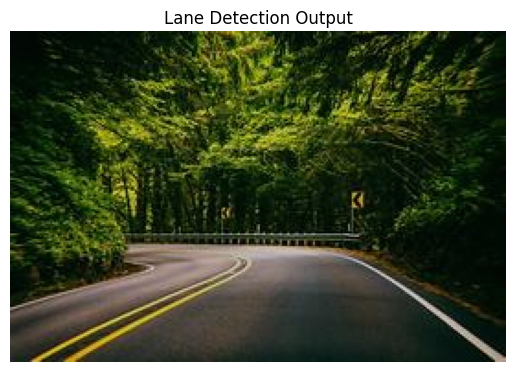

In [ ]:
# Display
plt.imshow(final_image)
plt.title("Lane Detection Output")
plt.axis("off")
plt.show()